# OntoNotes5 (tner/ontonotes5) Dataset Analysis

This notebook analyzes a 250-example subset of the OntoNotes5 NER dataset (via `tner/ontonotes5`) used in this project.

Target NER classes:
- Person
- Location
- Organization
- Time
- Currency


In [18]:
import json
import os
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

DATA_PATH = "ontonotes5_raw_ner_250.json"

# Original OntoNotes label mapping (name -> id)
LABEL_NAME2ID = {
    "O": 0,
    "B-CARDINAL": 1,
    "B-DATE": 2,
    "I-DATE": 3,
    "B-PERSON": 4,
    "I-PERSON": 5,
    "B-NORP": 6,
    "B-GPE": 7,
    "I-GPE": 8,
    "B-LAW": 9,
    "I-LAW": 10,
    "B-ORG": 11,
    "I-ORG": 12,
    "B-PERCENT": 13,
    "I-PERCENT": 14,
    "B-ORDINAL": 15,
    "B-MONEY": 16,
    "I-MONEY": 17,
    "B-WORK_OF_ART": 18,
    "I-WORK_OF_ART": 19,
    "B-FAC": 20,
    "B-TIME": 21,
    "I-CARDINAL": 22,
    "B-LOC": 23,
    "B-QUANTITY": 24,
    "I-QUANTITY": 25,
    "I-NORP": 26,
    "I-LOC": 27,
    "B-PRODUCT": 28,
    "I-TIME": 29,
    "B-EVENT": 30,
    "I-EVENT": 31,
    "I-FAC": 32,
    "B-LANGUAGE": 33,
    "I-PRODUCT": 34,
    "I-ORDINAL": 35,
    "I-LANGUAGE": 36,
}

# Inverse mapping (id -> name) for convenience
LABEL_ID2NAME = {v: k for k, v in LABEL_NAME2ID.items()}


In [19]:
# Load dataset
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Dataset file not found: {DATA_PATH}. Run the data loader first.")

with open(DATA_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

# Map numeric label IDs to OntoNotes string labels using LABEL_ID2NAME
for item in data:
    mapped = []
    for lab in item["labels"]:
        # lab is an int (or stringified int in some edge cases)
        try:
            lab_id = int(lab)
        except ValueError:
            # Already a string label (e.g., "B-PERSON")
            mapped.append(str(lab))
            continue
        mapped.append(LABEL_ID2NAME.get(lab_id, "O"))
    item["labels"] = mapped

print(f"Dataset loaded: {len(data)} sentences")
print("Labels converted from IDs to OntoNotes tag strings.")


Dataset loaded: 250 sentences
Labels converted from IDs to OntoNotes tag strings.


Label distribution (original OntoNotes tags):
O              :  5104
I-DATE         :   145
I-ORG          :   114
B-DATE         :   111
B-PERSON       :   111
I-MONEY        :    99
B-ORG          :    98
B-GPE          :    91
I-PERSON       :    60
I-PERCENT      :    51
B-MONEY        :    47
B-PERCENT      :    38
B-CARDINAL     :    28
B-NORP         :    25
I-WORK_OF_ART  :    12
I-CARDINAL     :    10
B-WORK_OF_ART  :     9
I-GPE          :     8
B-ORDINAL      :     4
B-LOC          :     3
I-LAW          :     2
I-QUANTITY     :     2
B-LAW          :     1
B-FAC          :     1
B-TIME         :     1
B-QUANTITY     :     1


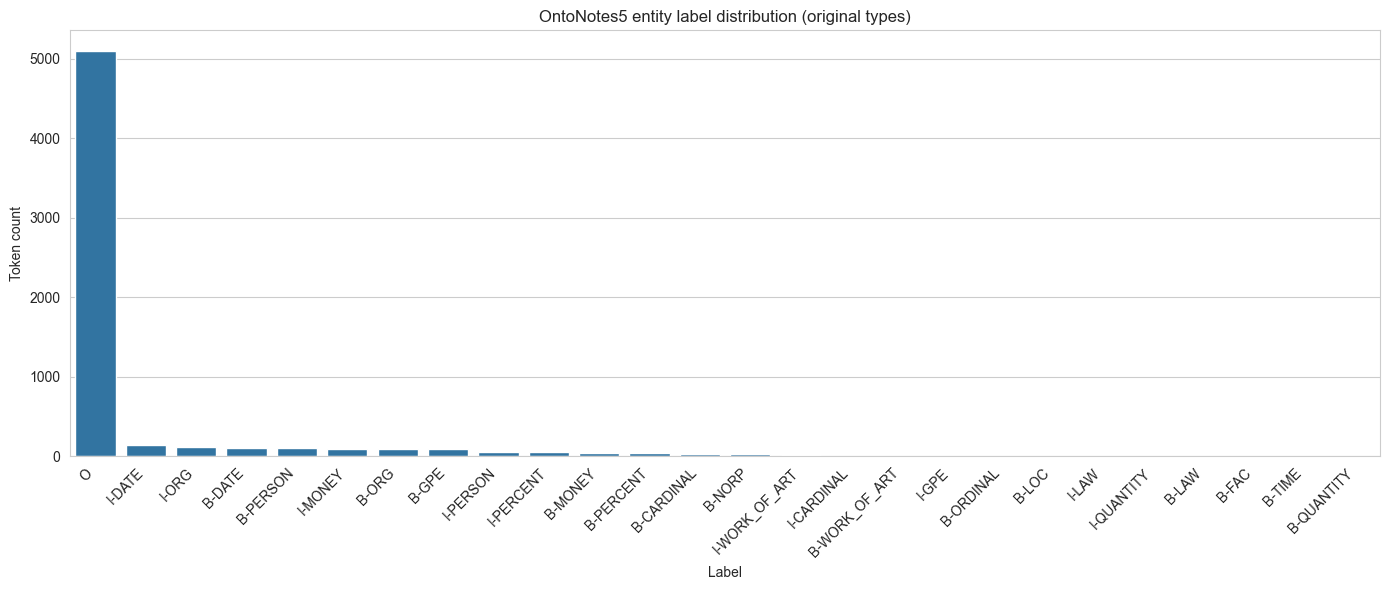

In [20]:
# Simple visualization of OntoNotes5 original entity types
from collections import Counter

# Flatten all labels
all_labels = [lab for item in data for lab in item["labels"]]
label_counts = Counter(all_labels)

print("Label distribution (original OntoNotes tags):")
for lab, cnt in sorted(label_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"{lab:15s}: {cnt:5d}")

# Bar plot of label frequencies
labels, counts = zip(*sorted(label_counts.items(), key=lambda x: x[1], reverse=True))

plt.figure(figsize=(14, 6))
sns.barplot(x=list(labels), y=list(counts))
plt.xticks(rotation=45, ha="right")
plt.title("OntoNotes5 entity label distribution (original types)")
plt.ylabel("Token count")
plt.xlabel("Label")
plt.tight_layout()
plt.show()


## 1. Basic Statistics


In [21]:
# Basic statistics
sentence_lengths = [len(item["tokens"]) for item in data]
text_lengths = [len(item["text"]) for item in data]

stats = {
    "Total Sentences": len(data),
    "Total Tokens": sum(sentence_lengths),
    "Avg Tokens per Sentence": np.mean(sentence_lengths),
    "Median Tokens per Sentence": np.median(sentence_lengths),
    "Min Tokens": np.min(sentence_lengths),
    "Max Tokens": np.max(sentence_lengths),
    "Avg Text Length": np.mean(text_lengths),
    "Median Text Length": np.median(text_lengths),
}

for key, value in stats.items():
    if isinstance(value, float):
        print(f"{key}: {value:.2f}")
    else:
        print(f"{key}: {value}")


Total Sentences: 250
Total Tokens: 6176
Avg Tokens per Sentence: 24.70
Median Tokens per Sentence: 24.00
Min Tokens: 3
Max Tokens: 57
Avg Text Length: 132.47
Median Text Length: 132.50


## 2. Entity Type Distribution (5 Classes)


In [22]:
PROJECT_ENTITY_TYPES = ["PERSON", "LOCATION", "ORGANIZATION", "TIME", "CURRENCY"]

entity_counts = {t: 0 for t in PROJECT_ENTITY_TYPES}
entity_mentions = {t: 0 for t in PROJECT_ENTITY_TYPES}

for item in data:
    labels = item["labels"]
    current_entity = None

    for label in labels:
        if label.startswith("B-"):
            # end previous
            if current_entity is not None:
                entity_counts[current_entity] += 1
            ent = label[2:]
            if ent in entity_mentions:
                entity_mentions[ent] += 1
                current_entity = ent
        elif label.startswith("I-"):
            ent = label[2:]
            if ent == current_entity:
                entity_mentions[ent] += 1
            else:
                # new entity starting with I-
                if current_entity is not None:
                    entity_counts[current_entity] += 1
                if ent in entity_mentions:
                    entity_mentions[ent] += 1
                    current_entity = ent
        else:
            if current_entity is not None:
                entity_counts[current_entity] += 1
                current_entity = None

    if current_entity is not None:
        entity_counts[current_entity] += 1

print("Entity Distribution (5 classes):")
print("=" * 60)
for ent in PROJECT_ENTITY_TYPES:
    print(f"{ent}:")
    print(f"  Entities: {entity_counts[ent]}")
    print(f"  Token Mentions: {entity_mentions[ent]}")
    print()


Entity Distribution (5 classes):
PERSON:
  Entities: 111
  Token Mentions: 171

LOCATION:
  Entities: 0
  Token Mentions: 0

ORGANIZATION:
  Entities: 0
  Token Mentions: 0

TIME:
  Entities: 1
  Token Mentions: 1

CURRENCY:
  Entities: 0
  Token Mentions: 0



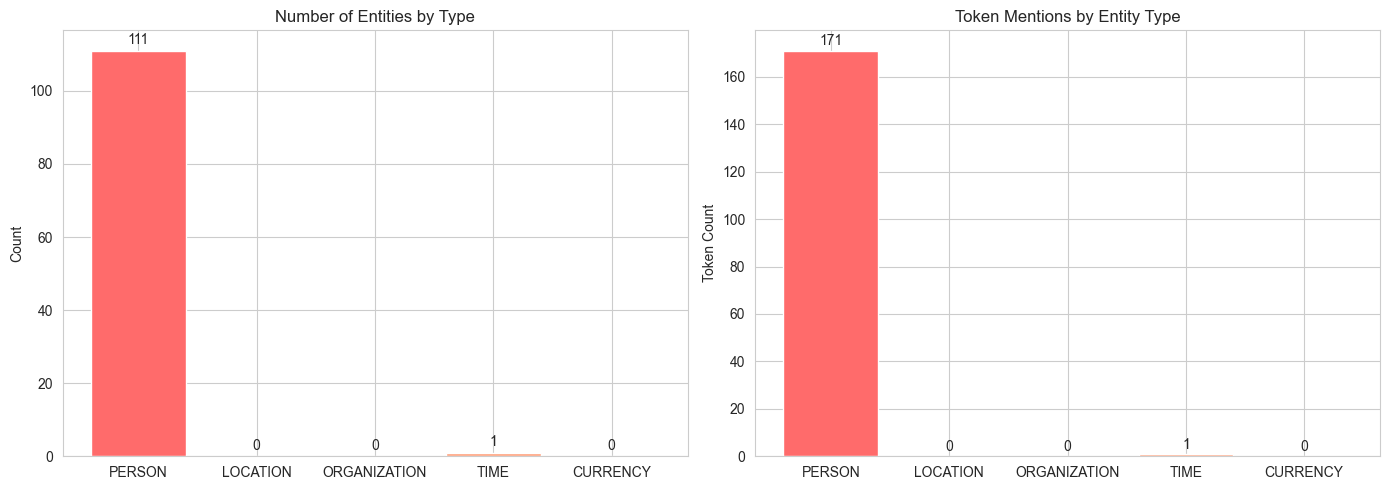

In [23]:
# Visualize entity distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

etypes = PROJECT_ENTITY_TYPES
counts = [entity_counts[e] for e in etypes]
mentions = [entity_mentions[e] for e in etypes]

axes[0].bar(etypes, counts, color=["#FF6B6B", "#4ECDC4", "#45B7D1", "#FFA07A", "#95A5A6"])
axes[0].set_title("Number of Entities by Type")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts):
    axes[0].text(i, v + 1, str(v), ha="center", va="bottom")

axes[1].bar(etypes, mentions, color=["#FF6B6B", "#4ECDC4", "#45B7D1", "#FFA07A", "#95A5A6"])
axes[1].set_title("Token Mentions by Entity Type")
axes[1].set_ylabel("Token Count")
for i, v in enumerate(mentions):
    axes[1].text(i, v + 1, str(v), ha="center", va="bottom")

plt.tight_layout()
plt.show()


## 3. Sentence Length Distribution


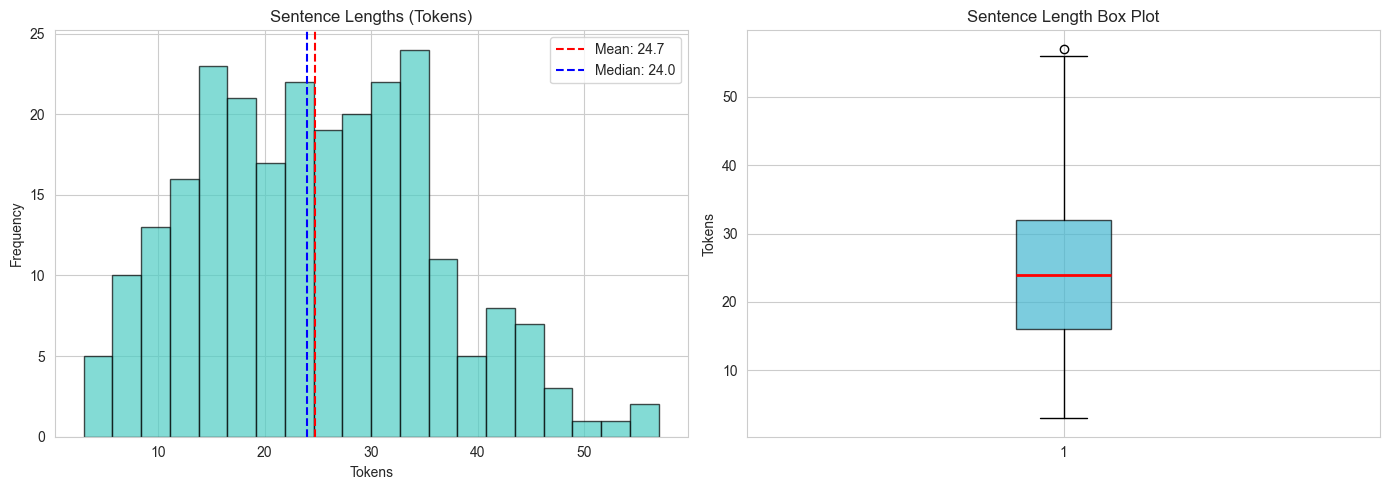

In [24]:
# Visualize sentence length distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(sentence_lengths, bins=20, color="#4ECDC4", edgecolor="black", alpha=0.7)
axes[0].set_title("Sentence Lengths (Tokens)")
axes[0].set_xlabel("Tokens")
axes[0].set_ylabel("Frequency")
axes[0].axvline(np.mean(sentence_lengths), color="red", linestyle="--", label=f"Mean: {np.mean(sentence_lengths):.1f}")
axes[0].axvline(np.median(sentence_lengths), color="blue", linestyle="--", label=f"Median: {np.median(sentence_lengths):.1f}")
axes[0].legend()

axes[1].boxplot(sentence_lengths, vert=True, patch_artist=True,
                boxprops=dict(facecolor="#45B7D1", alpha=0.7),
                medianprops=dict(color="red", linewidth=2))
axes[1].set_title("Sentence Length Box Plot")
axes[1].set_ylabel("Tokens")

plt.tight_layout()
plt.show()


## 4. Label Distribution


In [25]:
all_labels = []
for item in data:
    all_labels.extend(item["labels"])

label_counts = Counter(all_labels)

print("Label Distribution (BIO):")
print("=" * 60)
for lab, cnt in label_counts.most_common():
    pct = cnt / len(all_labels) * 100
    print(f"{lab:15s}: {cnt:5d} ({pct:5.2f}%)")


Label Distribution (BIO):
O              :  5104 (82.64%)
I-DATE         :   145 ( 2.35%)
I-ORG          :   114 ( 1.85%)
B-DATE         :   111 ( 1.80%)
B-PERSON       :   111 ( 1.80%)
I-MONEY        :    99 ( 1.60%)
B-ORG          :    98 ( 1.59%)
B-GPE          :    91 ( 1.47%)
I-PERSON       :    60 ( 0.97%)
I-PERCENT      :    51 ( 0.83%)
B-MONEY        :    47 ( 0.76%)
B-PERCENT      :    38 ( 0.62%)
B-CARDINAL     :    28 ( 0.45%)
B-NORP         :    25 ( 0.40%)
I-WORK_OF_ART  :    12 ( 0.19%)
I-CARDINAL     :    10 ( 0.16%)
B-WORK_OF_ART  :     9 ( 0.15%)
I-GPE          :     8 ( 0.13%)
B-ORDINAL      :     4 ( 0.06%)
B-LOC          :     3 ( 0.05%)
I-LAW          :     2 ( 0.03%)
I-QUANTITY     :     2 ( 0.03%)
B-LAW          :     1 ( 0.02%)
B-FAC          :     1 ( 0.02%)
B-TIME         :     1 ( 0.02%)
B-QUANTITY     :     1 ( 0.02%)


## 9. Data Cleaning - Map to Target Entity Types

First, we need to clean the labels to map all 18 OntoNotes entity types to our 5 target types:
- **Person** (PERSON)
- **Location** (GPE, LOC -> LOCATION)
- **Organization** (ORG -> ORGANIZATION)  
- **Time** (DATE -> TIME, drop original TIME if insufficient)
- **Currency** (MONEY -> CURRENCY)
- **MISC** (everything else -> MISC)


In [26]:
# Clean and map entity labels to target types
def map_label_to_target(label):
    """Map OntoNotes labels to our target entity types"""
    if label == 'O':
        return 'O'
    
    prefix = label[:2]  # 'B-' or 'I-'
    entity_type = label[2:]  # Entity type without prefix
    
    # Mapping rules
    if entity_type == 'PERSON':
        return f'{prefix}PERSON'
    elif entity_type in ['GPE', 'LOC']:  # GPE = geopolitical entity, LOC = location
        return f'{prefix}LOCATION'
    elif entity_type == 'ORG':
        return f'{prefix}ORGANIZATION'
    elif entity_type == 'DATE':
        return f'{prefix}TIME'  # Map DATE to TIME
    elif entity_type == 'MONEY':
        return f'{prefix}CURRENCY'
    elif entity_type == 'TIME':
        # Drop original TIME (insufficient samples), convert to MISC
        return f'{prefix}MISC'
    else:
        # Everything else maps to MISC
        return f'{prefix}MISC'

# Clean the data
cleaned_data = []
for item in data:
    cleaned_item = item.copy()
    cleaned_labels = [map_label_to_target(label) for label in item['labels']]
    cleaned_item['labels'] = cleaned_labels
    cleaned_data.append(cleaned_item)

# Update data variable
data = cleaned_data

print(f"Data cleaned: {len(data)} sentences")
print("Label mapping:")
print("  PERSON -> PERSON")
print("  GPE, LOC -> LOCATION")
print("  ORG -> ORGANIZATION")
print("  DATE -> TIME")
print("  MONEY -> CURRENCY")
print("  TIME (original) -> MISC (insufficient samples)")
print("  Everything else -> MISC")


Data cleaned: 250 sentences
Label mapping:
  PERSON -> PERSON
  GPE, LOC -> LOCATION
  ORG -> ORGANIZATION
  DATE -> TIME
  MONEY -> CURRENCY
  TIME (original) -> MISC (insufficient samples)
  Everything else -> MISC


In [27]:
# Verify cleaned entity distribution
print("="*60)
print("CLEANED ENTITY DISTRIBUTION")
print("="*60)

target_types = ['PERSON', 'LOCATION', 'ORGANIZATION', 'TIME', 'CURRENCY', 'MISC']
entity_counts = {t: 0 for t in target_types}
entity_mentions = {t: 0 for t in target_types}

for item in data:
    labels = item["labels"]
    current_entity = None

    for label in labels:
        if label.startswith("B-"):
            # end previous
            if current_entity is not None:
                entity_counts[current_entity] += 1
            ent = label[2:]
            if ent in entity_mentions:
                entity_mentions[ent] += 1
                current_entity = ent
        elif label.startswith("I-"):
            ent = label[2:]
            if ent == current_entity:
                entity_mentions[ent] += 1
            else:
                # new entity starting with I-
                if current_entity is not None:
                    entity_counts[current_entity] += 1
                if ent in entity_mentions:
                    entity_mentions[ent] += 1
                    current_entity = ent
        else:
            if current_entity is not None:
                entity_counts[current_entity] += 1
                current_entity = None

    if current_entity is not None:
        entity_counts[current_entity] += 1

print("\nEntity Distribution (after cleaning):")
for ent in target_types:
    print(f"  {ent}: {entity_counts[ent]} entities, {entity_mentions[ent]} token mentions")


CLEANED ENTITY DISTRIBUTION

Entity Distribution (after cleaning):
  PERSON: 111 entities, 171 token mentions
  LOCATION: 94 entities, 102 token mentions
  ORGANIZATION: 98 entities, 212 token mentions
  TIME: 111 entities, 256 token mentions
  CURRENCY: 53 entities, 146 token mentions
  MISC: 108 entities, 185 token mentions


In [28]:
import pandas as pd

# Convert to DataFrame for easier manipulation
df_data = pd.DataFrame(data)

# Calculate sentence metrics
df_data['token_count'] = df_data['tokens'].apply(len)
df_data['char_count'] = df_data['text'].apply(len)

# Calculate entity richness score (count of entities from target types, excluding MISC)
def calculate_entity_score(labels):
    """Count entities from our 4 target types (PERSON, LOCATION, ORGANIZATION, TIME, CURRENCY)"""
    target_types = ['PERSON', 'LOCATION', 'ORGANIZATION', 'TIME', 'CURRENCY']
    entity_count = 0
    current_entity = None
    
    for label in labels:
        if label.startswith('B-'):
            if current_entity is not None:
                entity_count += 1
            ent_type = label[2:]
            if ent_type in target_types:
                current_entity = ent_type
            else:
                current_entity = None
        elif label.startswith('I-'):
            ent_type = label[2:]
            if ent_type == current_entity:
                pass  # Continue counting same entity
            else:
                if current_entity is not None:
                    entity_count += 1
                if ent_type in target_types:
                    current_entity = ent_type
                else:
                    current_entity = None
        else:
            if current_entity is not None:
                entity_count += 1
                current_entity = None
    
    if current_entity is not None:
        entity_count += 1
    
    return entity_count

df_data['entity_score'] = df_data['labels'].apply(calculate_entity_score)

print(f"Dataset prepared: {len(df_data)} sentences")
print(f"Entity scores range: {df_data['entity_score'].min()} - {df_data['entity_score'].max()}")
print(f"Sentences with target entities: {(df_data['entity_score'] > 0).sum()}")

# Calculate quantiles for length distribution
q25 = df_data['token_count'].quantile(0.25)
q50 = df_data['token_count'].quantile(0.50)
q75 = df_data['token_count'].quantile(0.75)

print(f"\nToken Count Quantiles:")
print(f"  Q25: {q25:.0f}, Q50: {q50:.0f}, Q75: {q75:.0f} tokens")


Dataset prepared: 250 sentences
Entity scores range: 0 - 12
Sentences with target entities: 176

Token Count Quantiles:
  Q25: 16, Q50: 24, Q75: 32 tokens


In [29]:
def select_stratified_samples(df, target_count=140):
    """
    Select stratified samples using:
    1. Length stratification (short, medium, long)
    2. Entity richness (prioritize sentences with entities from target types)
    
    Args:
        df: DataFrame with sentences
        target_count: Number of samples to select (default: 140)
    
    Returns:
        Selected DataFrame
    """
    # Calculate quartiles
    q25 = df['token_count'].quantile(0.25)
    q75 = df['token_count'].quantile(0.75)
    
    # Define length categories
    short = df[df['token_count'] <= q25].copy()
    medium = df[(df['token_count'] > q25) & (df['token_count'] <= q75)].copy()
    long = df[df['token_count'] > q75].copy()
    
    # Allocation: 20% short, 60% medium, 20% long
    n_short = int(target_count * 0.2)
    n_medium = int(target_count * 0.6)
    n_long = target_count - n_short - n_medium
    
    selected_indices = []
    
    def select_from_category(category_df, n_select):
        """Select n_select sentences from category, prioritizing entity-rich content"""
        if len(category_df) == 0:
            return []
        
        # Sort by entity score (descending) and then by token count (for variety)
        category_df_sorted = category_df.sort_values(['entity_score', 'token_count'], ascending=[False, True])
        
        # Select top n_select
        selected = category_df_sorted.head(n_select).index.tolist()
        return selected
    
    # Select from each category
    selected_indices.extend(select_from_category(short, n_short))
    selected_indices.extend(select_from_category(medium, n_medium))
    selected_indices.extend(select_from_category(long, n_long))
    
    # Get final selection
    selected_df = df.loc[selected_indices].copy()
    
    return selected_df

# Execute selection
print("="*60)
print("SELECTING 140 EXAMPLES")
print("="*60)

selected_df = select_stratified_samples(df_data, target_count=140)

print(f"\nSelection Complete!")
print(f"  Total selected: {len(selected_df)} sentences")


SELECTING 140 EXAMPLES

Selection Complete!
  Total selected: 140 sentences


In [30]:
# Detailed analysis of selected samples
print("="*60)
print("SELECTED SAMPLES ANALYSIS")
print("="*60)

print(f"\nTotal selected: {len(selected_df)}")
print(f"\nToken count:")
print(f"  Min={selected_df['token_count'].min():.0f}, "
      f"Mean={selected_df['token_count'].mean():.1f}, "
      f"Median={selected_df['token_count'].median():.0f}, "
      f"Max={selected_df['token_count'].max():.0f}")

print(f"\nCharacter count:")
print(f"  Min={selected_df['char_count'].min():.0f}, "
      f"Mean={selected_df['char_count'].mean():.1f}, "
      f"Median={selected_df['char_count'].median():.0f}, "
      f"Max={selected_df['char_count'].max():.0f}")

print(f"\nEntity score:")
print(f"  Min={selected_df['entity_score'].min()}, "
      f"Mean={selected_df['entity_score'].mean():.2f}, "
      f"Max={selected_df['entity_score'].max()}")
print(f"  Sentences with entities: {(selected_df['entity_score'] > 0).sum()}")

# Length distribution
q25_sel = selected_df['token_count'].quantile(0.25)
q75_sel = selected_df['token_count'].quantile(0.75)
short_sel = len(selected_df[selected_df['token_count'] <= q25_sel])
medium_sel = len(selected_df[(selected_df['token_count'] > q25_sel) & (selected_df['token_count'] <= q75_sel)])
long_sel = len(selected_df[selected_df['token_count'] > q75_sel])
print(f"\nLength distribution:")
print(f"  Short: {short_sel}, Medium: {medium_sel}, Long: {long_sel}")


SELECTED SAMPLES ANALYSIS

Total selected: 140

Token count:
  Min=8, Mean=25.4, Median=24, Max=56

Character count:
  Min=34, Mean=136.6, Median=134, Max=337

Entity score:
  Min=1, Mean=2.83, Max=12
  Sentences with entities: 140

Length distribution:
  Short: 35, Medium: 72, Long: 33


/var/folders/97/qhn67ff95n3brkkxszz9k2w40000gp/T/ipykernel_6762/3546818562.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax4.boxplot(box_data, labels=['All', 'Selected'], patch_artist=True,


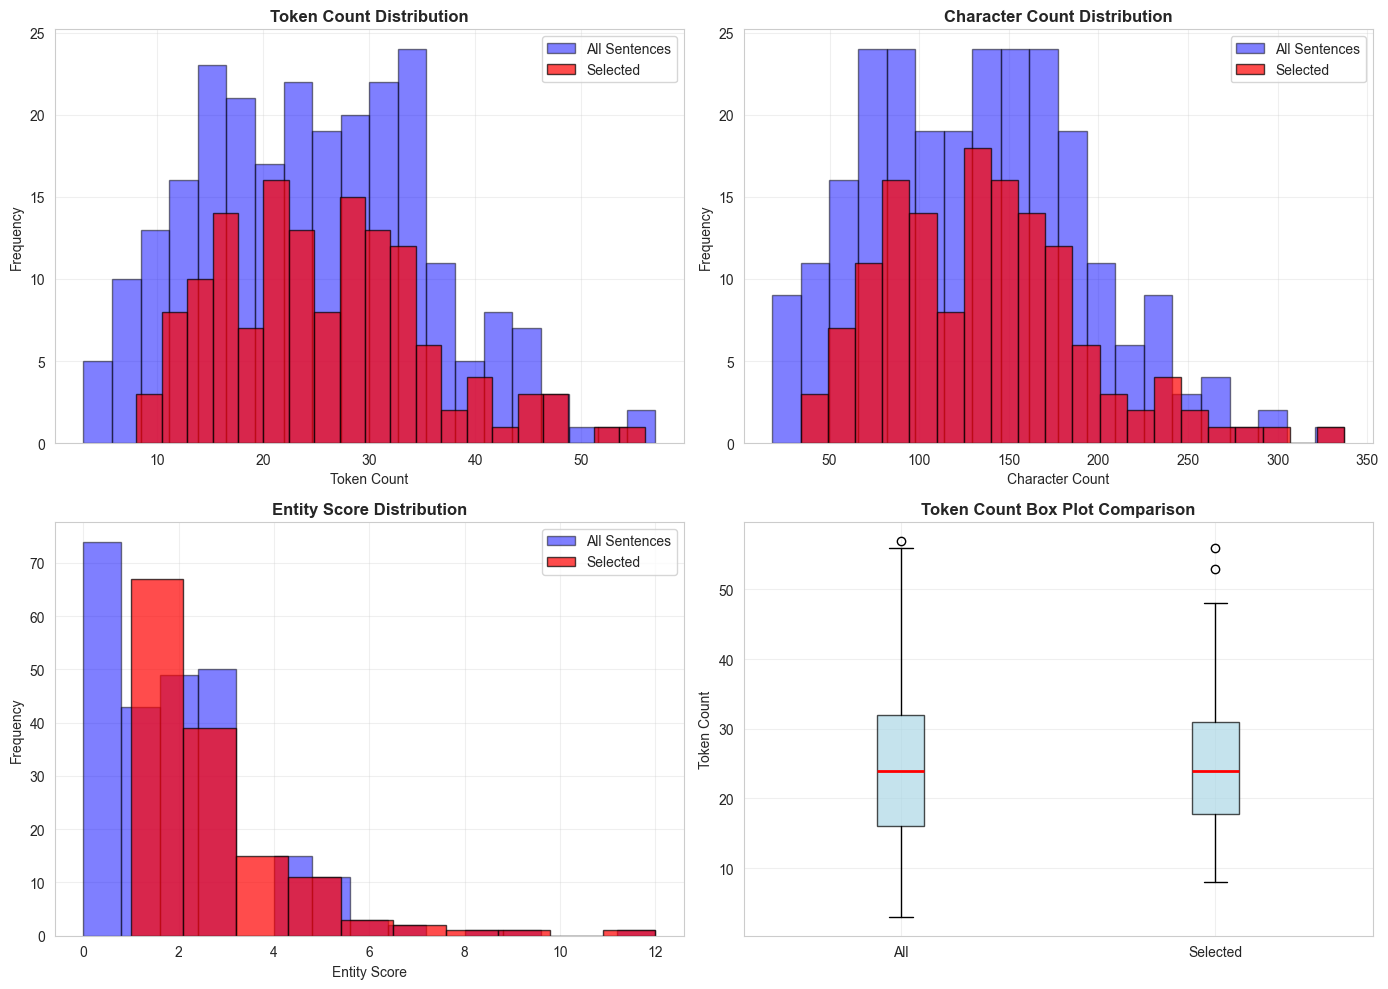

In [31]:
# Visualize selection vs original distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Token count comparison
ax1 = axes[0, 0]
ax1.hist(df_data['token_count'], bins=20, alpha=0.5, label='All Sentences', color='blue', edgecolor='black')
ax1.hist(selected_df['token_count'], bins=20, alpha=0.7, label='Selected', color='red', edgecolor='black')
ax1.set_title('Token Count Distribution', fontsize=12, fontweight='bold')
ax1.set_xlabel('Token Count')
ax1.set_ylabel('Frequency')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Character count comparison
ax2 = axes[0, 1]
ax2.hist(df_data['char_count'], bins=20, alpha=0.5, label='All Sentences', color='blue', edgecolor='black')
ax2.hist(selected_df['char_count'], bins=20, alpha=0.7, label='Selected', color='red', edgecolor='black')
ax2.set_title('Character Count Distribution', fontsize=12, fontweight='bold')
ax2.set_xlabel('Character Count')
ax2.set_ylabel('Frequency')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Entity score comparison
ax3 = axes[1, 0]
ax3.hist(df_data['entity_score'], bins=15, alpha=0.5, label='All Sentences', color='blue', edgecolor='black')
ax3.hist(selected_df['entity_score'], bins=10, alpha=0.7, label='Selected', color='red', edgecolor='black')
ax3.set_title('Entity Score Distribution', fontsize=12, fontweight='bold')
ax3.set_xlabel('Entity Score')
ax3.set_ylabel('Frequency')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Box plot comparison
ax4 = axes[1, 1]
box_data = [df_data['token_count'], selected_df['token_count']]
ax4.boxplot(box_data, labels=['All', 'Selected'], patch_artist=True,
            boxprops=dict(facecolor='lightblue', alpha=0.7),
            medianprops=dict(color='red', linewidth=2))
ax4.set_title('Token Count Box Plot Comparison', fontsize=12, fontweight='bold')
ax4.set_ylabel('Token Count')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [32]:
# Save selected samples to JSON file
selected_samples = []

for idx, row in selected_df.iterrows():
    sample = {
        'tokens': row['tokens'],
        'labels': row['labels'],
        'text': row['text'],
        'token_count': int(row['token_count']),
        'char_count': int(row['char_count']),
        'entity_score': int(row['entity_score'])
    }
    selected_samples.append(sample)

output_data = {
    'metadata': {
        'total_samples': len(selected_samples),
        'selection_date': pd.Timestamp.now().isoformat(),
        'selection_strategy': 'Stratified sampling by length and entity richness'
    },
    'samples': selected_samples
}

output_file = '/Users/zeynep_yilmaz/Desktop/ner_nlp/data/selected_140_ontonotes5_samples.json'
with open(output_file, 'w', encoding='utf-8') as f:
    json.dump(output_data, f, indent=2, ensure_ascii=False)

print(f"="*60)
print(f"SELECTED SAMPLES SAVED")
print(f"="*60)
print(f"File: {output_file}")
print(f"Total samples: {len(selected_samples)}")
print(f"\nFile saved successfully!")


SELECTED SAMPLES SAVED
File: /Users/zeynep_yilmaz/Desktop/ner_nlp/data/selected_140_ontonotes5_samples.json
Total samples: 140

File saved successfully!


## Summary of Selection Strategy

The selection strategy implemented for OntoNotes5:

1. **Data Cleaning**:
   - Mapped all 18 OntoNotes entity types to our target types
   - PERSON → PERSON
   - GPE, LOC → LOCATION
   - ORG → ORGANIZATION
   - DATE → TIME (original TIME dropped due to insufficient samples)
   - MONEY → CURRENCY
   - Everything else → MISC

2. **Length Stratification**:
   - 20% short sentences (≤Q25 token count)
   - 60% medium sentences (Q25-Q75 token count)
   - 20% long sentences (>Q75 token count)

3. **Entity Richness**:
   - Prioritizes sentences with entities from our 4 target types (PERSON, LOCATION, ORGANIZATION, TIME, CURRENCY)
   - Excludes MISC from scoring to focus on target entity types
   - Within each length category, sentences are sorted by entity score (higher = better)

4. **Diversity**:
   - Ensures representation across the full length distribution
   - Balances entity-rich content with length variety

This strategy ensures:
- ✅ Cleaned entity types mapped correctly
- ✅ Length diversity (covers full distribution)
- ✅ Entity richness (better for NER task evaluation)
- ✅ Balanced selection across sentence lengths
